In [1]:
from pyspark.sql.functions import col, explode, map_from_arrays, array, lit, when

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 3, Finished, Available, Finished, False)

In [4]:
path = "Files/anonymised_issue_data_no_comments.json"
df = spark.read.option("multiline", "true").json(path)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 6, Finished, Available, Finished, False)

In [6]:
df_issues = df.select(explode("issues").alias("issue"))

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 8, Finished, Available, Finished, False)

In [10]:
from pyspark.sql.functions import col

issues_base = df_issues.select(
    col("issue.Id").alias("issue_id"),
    col("issue.Title").alias("title"),
    col("issue.Type").alias("type"),
    col("issue.RaisedAtTimestamp").alias("raised_at"),
    col("issue.DateIdentified").alias("date_identified"),
    col("issue.DateOccurred").alias("date_occurred"),
    col("issue.CreatedAtTimestamp").alias("created_at"),
    col("issue.ModifiedAtTimestamp").alias("modified_at"),
    col("issue.SequentialId").alias("sequential_id"),
    col("issue.ImpactsCustomer").alias("impacts_customer"),
    col("issue.IsExternalIssue").alias("is_external_issue"),
    col("issue.issueStatus.Status").alias("status"),
    col("issue.createdByUser.Id").alias("created_by"),
    col("issue.modifiedByUser.Id").alias("modified_by")
)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 12, Finished, Available, Finished, False)

In [28]:
issues_base.write.mode("overwrite").saveAsTable("src_issue")


StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 30, Finished, Available, Finished, False)

In [11]:
display(src_issue)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 13, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 59f76379-3fb3-400c-8085-8aabad40febf)

In [12]:
from pyspark.sql.functions import col, explode_outer

owners = df_issues.select(
    col("issue.Id").alias("issue_id"),
    explode_outer("issue.owners").alias("owner")
).select(
    "issue_id",
    col("owner.user.Id").alias("owner_id"),
    col("owner.user.FriendlyName").alias("owner_name"),
    col("owner.user.Email").alias("owner_email")
)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 14, Finished, Available, Finished, False)

In [13]:
display(owners)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 15, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 931f5314-a00b-489e-8b4b-628a43d75761)

In [27]:
owners.write.mode("overwrite").saveAsTable("src_owner")


StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 29, Finished, Available, Finished, False)

In [47]:
from pyspark.sql.functions import col, explode_outer

attachments = df_issues.select(
    col("issue.Id").alias("issue_id"),
    explode_outer("issue.attachments").alias("attachment")
).select(
    "issue_id",
    col("attachment.attachment_id").alias("attachment_id"),
    col("attachment.file_name").alias("file_name"),
    col("attachment.uploaded_at").alias("uploaded_at"),
    col("attachment.size_bytes").alias("size_bytes"),
    col("attachment.source").alias("source")
)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 49, Finished, Available, Finished, False)

In [48]:
display(attachments)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 50, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 451403a1-10ce-4296-93c8-f54cd9ce670d)

In [49]:
attachments.write.mode("overwrite").saveAsTable("src_attachment")


StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 51, Finished, Available, Finished, False)

In [14]:
departments = df_issues.select(
    col("issue.Id").alias("issue_id"),
    explode_outer("issue.departments").alias("dept")
).select(
    "issue_id",
    col("dept.type.DepartmentTypeId").alias("department_id"),
    col("dept.type.Name").alias("department_name")
)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 16, Finished, Available, Finished, False)

In [15]:
display(departments)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 17, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 8ccbfd3e-0cc3-4561-8694-ab3223832a33)

In [24]:
departments.write.mode("overwrite").saveAsTable("src_department")


StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 26, Finished, Available, Finished, False)

In [16]:
contributors = df_issues.select(
    col("issue.Id").alias("issue_id"),
    explode_outer("issue.contributors").alias("contributor")
).select(
    "issue_id",
    col("contributor.user.Id").alias("contributor_id"),
    col("contributor.user.FriendlyName").alias("contributor_name"),
    col("contributor.user.Email").alias("contributor_email")
)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 18, Finished, Available, Finished, False)

In [17]:
display(contributors)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 19, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, d7019cf4-29b3-45aa-bc76-91dcce80d7af)

In [23]:
contributors.write.mode("overwrite").saveAsTable("src_contributor")


StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 25, Finished, Available, Finished, False)

In [18]:
tags = df_issues.select(
    col("issue.Id").alias("issue_id"),
    explode_outer("issue.tags").alias("tag")
)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 20, Finished, Available, Finished, False)

In [19]:
display(tags)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 21, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, fe04b974-efbb-4edc-97da-8891da1601d2)

In [25]:
tags.write.mode("overwrite").saveAsTable("src_tag")


StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 27, Finished, Available, Finished, False)

In [20]:
events = df_issues.select(
    col("issue.Id").alias("issue_id"),
    explode_outer("issue.events").alias("event")
).select(
    "issue_id",
    col("event.event").alias("event_type"),
    col("event.timestamp"),
    col("event.carrier"),
    col("event.by.Id").alias("event_user_id"),
    col("event.by.FriendlyName").alias("event_user_name")
)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 22, Finished, Available, Finished, False)

In [26]:
events.write.mode("overwrite").saveAsTable("src_event")


StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 28, Finished, Available, Finished, False)

In [21]:
from pyspark.sql.functions import col, explode, from_json, to_json, array, when
from pyspark.sql.types import MapType, StringType, ArrayType

custom_map = df_issues.select(
    col("issue.Id").alias("issue_id"),
    from_json(
        to_json(col("issue.CustomAttributeData")),
        MapType(StringType(), StringType())
    ).alias("custom_map")
)

custom = custom_map.select(
    "issue_id",
    explode("custom_map").alias("key", "value")
)

custom_final = custom.withColumn(
    "value_array",
    from_json(col("value"), ArrayType(StringType()))
).withColumn(
    "value",
    explode(
        when(col("value_array").isNotNull(), col("value_array"))
        .otherwise(array(col("value")))
    )
).select("issue_id", "key", "value")

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 23, Finished, Available, Finished, False)

In [22]:
custom_final.write.mode("overwrite").saveAsTable("src_custom_attribute")


StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 24, Finished, Available, Finished, False)

In [34]:
from pyspark.sql.functions import col, when, to_timestamp

cols = ["raised_at", "date_identified", "date_occurred", "created_at","modified_at"]

for c in cols:
    df = df.withColumn(
        c,
        when(
            col(c).rlike("^[0-9]{13}$"),  # epoch in milliseconds
            (col(c).cast("double") / 1000).cast("timestamp")
        ).when(
            col(c).rlike("^[0-9]{10}$"),  # epoch in seconds (optional)
            col(c).cast("timestamp")
        ).otherwise(
            to_timestamp(col(c))  # ISO format
        )
    )

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 36, Finished, Available, Finished, False)

In [35]:
display(df)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 37, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 2fd03769-f12a-43bd-a9d7-01f37deb42d2)

In [36]:
df.write \
  .mode("overwrite") \
  .option("overwriteSchema", "true") \
  .saveAsTable("src_issue")

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 38, Finished, Available, Finished, False)

In [42]:
df2 = spark.table("src_event")

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 44, Finished, Available, Finished, False)

In [43]:
from pyspark.sql.functions import col, when, to_timestamp, regexp_replace

df2 = df2.withColumn(
    "timestamp",
    when(
        col("timestamp").rlike("^[0-9]{13}$"),
        (col("timestamp").cast("double") / 1000).cast("timestamp")
    ).when(
        col("timestamp").rlike("^[0-9]{10}$"),
        col("timestamp").cast("timestamp")
    ).otherwise(
        to_timestamp(
            regexp_replace(col("timestamp"), "Z$", "+00:00")
        )
    )
)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 45, Finished, Available, Finished, False)

In [44]:
df2.write \
  .mode("overwrite") \
  .option("overwriteSchema", "true") \
  .saveAsTable("src_event")

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 46, Finished, Available, Finished, False)

In [50]:
df3 = spark.table("issue_attachments_dim")

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 52, Finished, Available, Finished, False)

In [53]:
from pyspark.sql.functions import col, when, to_timestamp, regexp_replace

df3 = df3.withColumn(
    "uploaded_at",
    when(
        col("uploaded_at").rlike("^[0-9]{13}$"),
        (col("uploaded_at").cast("double") / 1000).cast("timestamp")
    ).when(
        col("uploaded_at").rlike("^[0-9]{10}$"),
        col("uploaded_at").cast("timestamp")
    ).otherwise(
        to_timestamp(
            regexp_replace(col("uploaded_at"), "Z$", "+00:00")
        )
    )
)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 55, Finished, Available, Finished, False)

In [54]:
df3.write \
  .mode("overwrite") \
  .option("overwriteSchema", "true") \
  .saveAsTable("src_attachment")

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 56, Finished, Available, Finished, False)

StatementMeta(, fb804607-c839-4324-850d-69240eb7a548, 60, Finished, Available, Finished, False)

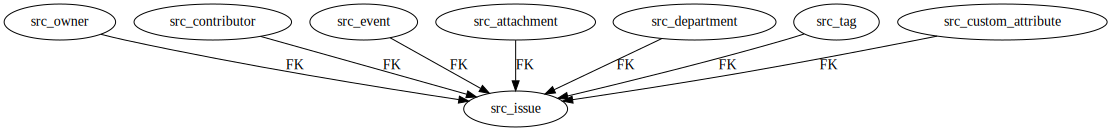

In [58]:
from graphviz import Digraph

dot = Digraph(comment='ERD')

# Tables
tables = [
    "src_issue",
    "src_owner",
    "src_contributor",
    "src_event",
    "src_attachment",
    "src_department",
    "src_tag",
    "src_custom_attribute"
]

for t in tables:
    dot.node(t, t)

# Relationships
relationships = [
    ("src_owner", "src_issue"),
    ("src_contributor", "src_issue"),
    ("src_event", "src_issue"),
    ("src_attachment", "src_issue"),
    ("src_department", "src_issue"),
    ("src_tag", "src_issue"),
    ("src_custom_attribute", "src_issue")
]

for child, parent in relationships:
    dot.edge(child, parent, label="FK")

dot

In [ ]:
%%sql
CREATE OR REPLACE TABLE fact_issue AS
SELECT
    issue_id,
    sequential_id,
    title,
    type,
    status,

    CAST(created_at AS DATE) AS created_date,
    CAST(date_occurred AS DATE) AS occurred_date,
    CAST(date_identified AS DATE) AS identified_date,

    COALESCE(impacts_customer, FALSE) AS impacts_customer,
    COALESCE(is_external_issue, FALSE) AS is_external_issue,

    1 AS issue_count,

    CASE 
        WHEN date_occurred IS NOT NULL 
         AND date_identified IS NOT NULL
        THEN DATEDIFF(day, date_occurred, date_identified)
    END AS days_to_identify

FROM src_issue;

In [5]:
%%sql
CREATE OR REPLACE TABLE fact_issue_owner AS
SELECT
    issue_id,
    owner_id,
    owner_name,
    owner_email,
    1 AS owner_count
FROM src_owner;

StatementMeta(, e3b969ee-1222-47b9-a2c1-d3a2fd1beacc, 7, Finished, Available, Finished, False)

<Spark SQL result set with 0 rows and 0 fields>

In [6]:
%%sql
CREATE OR REPLACE TABLE fact_issue_department AS
SELECT
    issue_id,
    department_id,
    department_name,
    1 AS department_count
FROM src_department;

StatementMeta(, e3b969ee-1222-47b9-a2c1-d3a2fd1beacc, 8, Finished, Available, Finished, False)

<Spark SQL result set with 0 rows and 0 fields>

In [7]:
%%sql
CREATE OR REPLACE TABLE fact_issue_event AS
SELECT
    issue_id,
    event_type,
    timestamp,
    CAST(timestamp AS DATE) AS event_date,
    carrier,
    event_user_id,
    event_user_name,
    1 AS event_count
FROM src_event;

StatementMeta(, e3b969ee-1222-47b9-a2c1-d3a2fd1beacc, 9, Finished, Available, Finished, False)

<Spark SQL result set with 0 rows and 0 fields>

In [8]:
%%sql
CREATE OR REPLACE TABLE fact_attachment AS
SELECT
    issue_id,
    attachment_id,
    file_name,
    size_bytes,
    source,
    CAST(uploaded_at AS DATE) AS uploaded_date,
    1 AS attachment_count
FROM src_attachment;

StatementMeta(, e3b969ee-1222-47b9-a2c1-d3a2fd1beacc, 10, Finished, Available, Finished, False)

<Spark SQL result set with 0 rows and 0 fields>

In [9]:
%%sql
CREATE OR REPLACE TABLE fact_issue_tag AS
SELECT
    issue_id,
    tag,
    1 AS tag_count
FROM src_tag;

StatementMeta(, e3b969ee-1222-47b9-a2c1-d3a2fd1beacc, 11, Finished, Available, Finished, False)

<Spark SQL result set with 0 rows and 0 fields>

In [10]:
%%sql
CREATE OR REPLACE TABLE fact_issue_custom_attribute AS
SELECT
    issue_id,
    key AS attribute_key,
    value AS attribute_value,
    1 AS attribute_count
FROM src_custom_attribute
WHERE issue_id IS NOT NULL;

StatementMeta(, e3b969ee-1222-47b9-a2c1-d3a2fd1beacc, 12, Finished, Available, Finished, False)

<Spark SQL result set with 0 rows and 0 fields>

In [11]:
%%sql
CREATE OR REPLACE TABLE fact_issue_contributor AS
SELECT
    issue_id,
    contributor_id,
    contributor_name,
    contributor_email,
    1 AS contributor_count
FROM src_contributor
WHERE issue_id IS NOT NULL
  AND contributor_id IS NOT NULL;

StatementMeta(, e3b969ee-1222-47b9-a2c1-d3a2fd1beacc, 13, Finished, Available, Finished, False)

<Spark SQL result set with 0 rows and 0 fields>